https://www.kaggle.com/datasets/olistbr/brazilian-ecommerce

In [4]:
import pandas as pd 
import sqlite3
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import seaborn as sns
import kagglehub




In [5]:

path = kagglehub.dataset_download("olistbr/brazilian-ecommerce")

print("Path to dataset files:", path)

  7%|▋         | 3.00M/42.6M [00:02<00:36, 1.13MB/s]


KeyboardInterrupt: 

### Read the data

In [6]:
paths = [
    {"order_items": "data/olist_order_items_dataset.csv"},
    {"products": "data/olist_products_dataset.csv"}
]
conn = sqlite3.connect('olist_db.db')
for item in paths:
    for table_name, path in item.items():
        print(f"Reading {path} into {table_name} :")
        # csv -> dataframe 
        df = pd.read_csv(path)

        # writing csv to sql
        df.to_sql(table_name,conn,if_exists='replace',index=False)
    
print('Data saved to database')

Reading data/olist_order_items_dataset.csv into order_items :
Reading data/olist_products_dataset.csv into products :
Data saved to database


### Joining tables using ids

In [7]:
conn = sqlite3.connect('olist_db.db')

with open('queries/analysis_query.sql', 'r') as f:
    sql_script = f.read()

df_analysis = pd.read_sql_query(sql_script, conn)

print(df_analysis.head())

conn.close()

    product_category_name  total_orders  total_revenue   avg_price
0            beleza_saude          9670     1258681.34  130.163531
1      relogios_presentes          5991     1205005.68  201.135984
2         cama_mesa_banho         11115     1036988.68   93.296327
3           esporte_lazer          8641      988048.97  114.344285
4  informatica_acessorios          7827      911954.32  116.513903


### KMeans

Our target is to retrieve the most significant clusters in terms of revenue and build awareness on which categories matter for the business. 

In [8]:
# Choosing attributes 
X = df_analysis[['total_orders', 'total_revenue']]
scaler=StandardScaler()
# Scaling - it measures euclidean distances so we need to scale 
X_scaled = scaler.fit_transform(X)

model = KMeans(n_clusters=3, random_state=42)
df_analysis['cluster'] = model.fit_predict(X_scaled)

print(df_analysis.groupby('cluster')[['total_orders', 'total_revenue']].mean())

         total_orders  total_revenue
cluster                             
0          423.406780   5.623130e+04
1         8596.333333   1.021740e+06
2         4311.000000   4.955025e+05


### Silhouette score

In [9]:
score = silhouette_score(X_scaled, df_analysis['cluster'])
print(f"Silhouette Score: {score:.3f}")

Silhouette Score: 0.767


Silhouette 0.767 means the data is quite well-separated, clusters do not cover each other. Choosing k=3 was a good decision. Increasing k makes silhouette score lower.

### Inertia

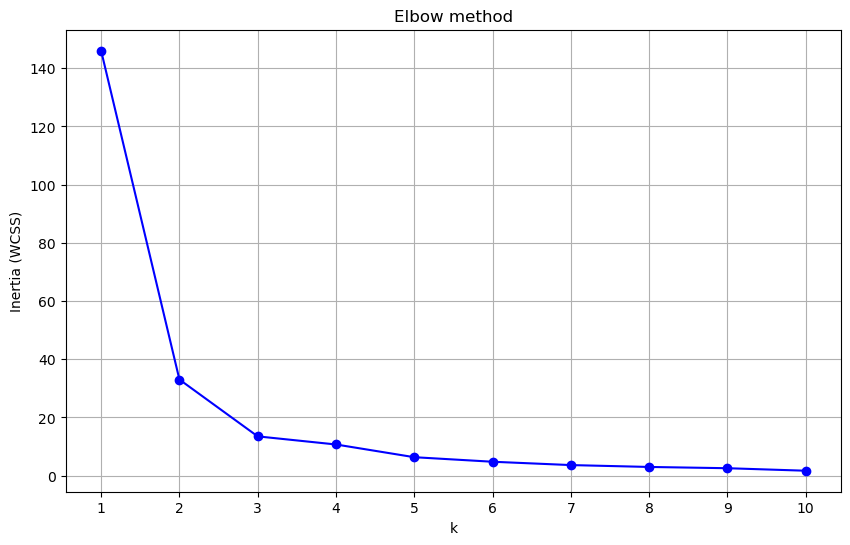

In [10]:
import matplotlib.pyplot as plt

inertia = []
K = range(1, 11)

for k in K:
    km = KMeans(n_clusters=k, random_state=42)
    km.fit(X_scaled)
    inertia.append(km.inertia_)

plt.figure(figsize=(10, 6))
plt.plot(K, inertia, 'bo-')
plt.xlabel('k')
plt.ylabel('Inertia (WCSS)')
plt.title('Elbow method')
plt.xticks(K)
plt.grid(True)
plt.show()

We can see after k=3 the graph stops to fall down significantly. That means k=3 is a good choice. 

### Excel

In [11]:
cluster_map = {
    1: '1. The best ones (High Vol, High Rev)',
    2: '2. The stable ones (Mid Vol, Mid Rev)',
    0: '3. Lower (Low Vol, Low Rev)'
}
df_analysis['segment_name'] = df_analysis['cluster'].map(cluster_map)
df_analysis.to_excel("segmentation_olist.xlsx", index=False)

### Summary 

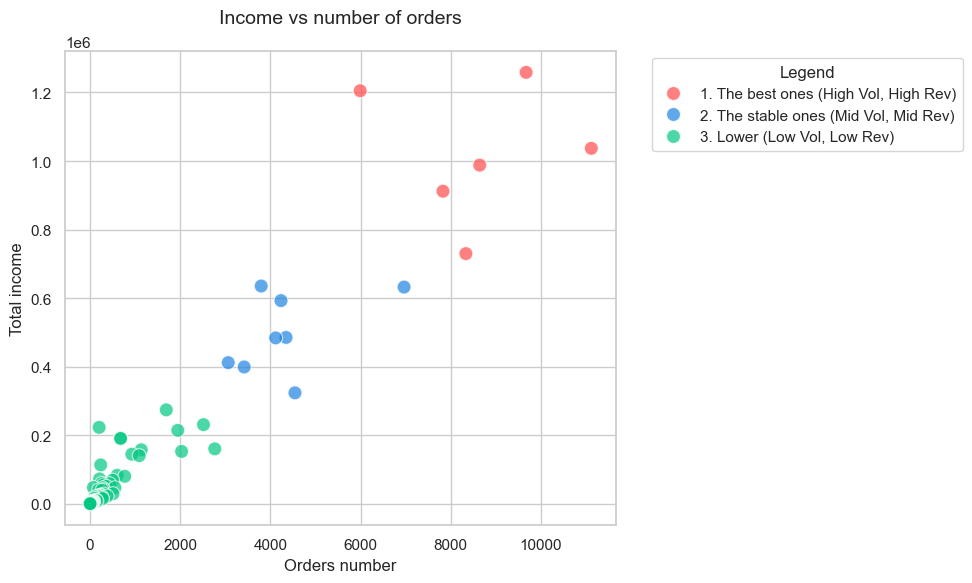

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style="whitegrid")
plt.figure(figsize=(10, 6))

scatter = sns.scatterplot(
    data=df_analysis, 
    x='total_orders', 
    y='total_revenue', 
    hue='segment_name', 
    palette=['#FF4B4B', '#1C83E1', '#00C781'], # Czerwony, Niebieski, Zielony
    s=100, 
    alpha=0.7
)

plt.title('Income vs number of orders', fontsize=14, pad=20)
plt.xlabel('Orders number', fontsize=12)
plt.ylabel('Total income', fontsize=12)
plt.legend(title='Legend', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()

plt.show()

1. The correlation between income and order numbers is approximately linear, though there are some outlier which we can mark as premium group because they do not need high volume for it to  
2. Three clusters identified:
- green cluster - majority of products are in this cluster, individually they make small amounts of many but as a group they provide stable source of income
- blue cluster - not the biggest but definetely consisten source of cash flow for the company
- red cluster - products have high market demand and customer's trust at the same time this categories' products are very expensive
3. I used KMeans clustering algorithm to identify which products drive the most value, which can help a business prioritize specific product categories to maximize its revenue.